# Wildfire Intensity Prediction
#### By Damiru Vidunitha Wanniarachchi (S4137361)

---

## How to Run
1. Place `wildfire_cls_train_full.csv` and `wildfire_cls_test_features.csv` in the same directory as this notebook
2. Run all cells top-to-bottom (`Kernel → Restart & Run All`).
3. The final cell saves `test_predictions.csv`.

---

# 1.0 Imports and Setup

In [1]:
import sys
!{sys.executable} -m pip install pandas numpy scikit-learn matplotlib seaborn


[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: pip3.11 install --upgrade pip


In [2]:
# Standard library
import warnings
warnings.filterwarnings('ignore')
import random
import numpy as np
import pandas as pd

# Visualisation
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Scikit-learn
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_val_score
)
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

# Models
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

# Metrics
from sklearn.metrics import (
    accuracy_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)

# Reproducibility
SEED = 7
random.seed(SEED)
np.random.seed(SEED)

# Plot style
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.15)
FIGSIZE = (10, 5)

CLASS_NAMES = ['Low (0)', 'Moderate (1)', 'High (2)', 'Extreme (3)']

print('All imports successful.')

All imports successful.


# 2.0 Data

## 2.1 Load Data

In [3]:
df_tr = pd.read_csv('dataset/wildfire_cls_train_full.csv')
df_te  = pd.read_csv('dataset/wildfire_cls_test_features.csv')

## 2.2 Exploratory Data Analysis (EDA)

### Overview of Data

In [4]:
print(f'Training set : {df_tr.shape[0]:,} rows × {df_tr.shape[1]} columns')
print(f'Test set     : {df_te.shape[0]:,} rows × {df_te.shape[1]} columns')

Training set : 4,340 rows × 20 columns
Test set     : 1,085 rows × 19 columns


The above shows that the *training dataset* contains 4340 entries and 20 features, whereas the *test dataset* contains 1085 entries and 19 features excluding the target variable `fire_intensity`.

In [5]:
df_tr.head()

,latitude,longitude,acq_date,acq_time,year,month,season,daynight,region,country,fire_type,satellite,instrument,brightness_k,confidence,temp_max_c,wind_max_kmh,precip_mm,humidity_pct,fire_intensity
0,-22.1967,-61.5275,2024-08-12,1838,2024,NaN,Winter,D,South_America,Peru,Deforestation,Suomi-NPP,VIIRS,360.26,nominal,40.6,39.0,0.11,17.1,Extreme
1,64.2205,-53.4116,2024-07-11,424,2024,7.0,Summer,N,North_America,Canada,Forest,Suomi-NPP,VIIRS,326.20,high,38.9,NaN,0.06,13.2,Low
2,38.6810,9.5739,2024-06-18,546,2024,6.0,Summer,N,Mediterranean,Spain,Wildfire,AQUA,MODIS,343.36,high,36.9,30.1,0.19,35.2,High
3,68.1959,-90.3475,2024-08-26,2240,2024,8.0,Summer,N,North_America,USA,Forest,TERRA,MODIS,389.16,nominal,43.8,17.7,0.98,32.8,Extreme
4,0.6527,118.6227,2025-08-09,2301,2025,8.0,Summer,N,Southeast_Asia,Malaysia,Peatland,TERRA,MODIS,335.68,high,34.8,1.0,0.18,83.2,Moderate


In [6]:
print('\nColumn dtypes\n')
print(df_tr.dtypes)
print('\nBasic statistics')
df_tr.describe(include='all').T


Column dtypes

latitude          float64
longitude         float64
acq_date              str
acq_time            int64
year                int64
month             float64
season                str
daynight              str
region                str
country               str
fire_type             str
satellite             str
instrument            str
brightness_k      float64
confidence            str
temp_max_c        float64
wind_max_kmh      float64
precip_mm         float64
humidity_pct      float64
fire_intensity        str
dtype: object

Basic statistics


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
latitude,4340.0,NaN,NaN,NaN,9.821703,24.321271,-42.9883,-8.611625,10.2685,29.011025,69.9309
longitude,4340.0,NaN,NaN,NaN,29.430626,78.8427,-167.9906,-40.9806,34.8337,95.166775,153.7549
acq_date,4340,709,2025-08-26,18,NaN,NaN,NaN,NaN,NaN,NaN,NaN
acq_time,4340.0,NaN,NaN,NaN,1177.046774,683.844117,0.0,602.0,1208.0,1752.0,2359.0
year,4340.0,NaN,NaN,NaN,2024.501843,0.500054,2024.0,2024.0,2025.0,2025.0,2025.0
month,3924.0,NaN,NaN,NaN,7.240316,2.791615,1.0,5.0,8.0,9.0,12.0
season,4340,4,Spring,1333,NaN,NaN,NaN,NaN,NaN,NaN,NaN
daynight,4340,2,D,2392,NaN,NaN,NaN,NaN,NaN,NaN,NaN
region,4340,7,South_Asia,895,NaN,NaN,NaN,NaN,NaN,NaN,NaN
country,4340,35,Australia,275,NaN,NaN,NaN,NaN,NaN,NaN,NaN


The `count` statistic presents the number of non-null values in the dataset for each feature. The above `count`s indicate the presence of **missing data** which should be analysed and handled appropriately.

It is important to note that 10 unique classes (types) of fires exist for the `fire_type` variable, indicating significant diversity of environmental contexts of these fires.

The most frequent `fire_intensity` (target variable) recorded is shown to be of 'Moderate' intensity.

The dataset is made up of wildfire data from 35 countries, giving it a more global perspective.

### Target Class Distribution

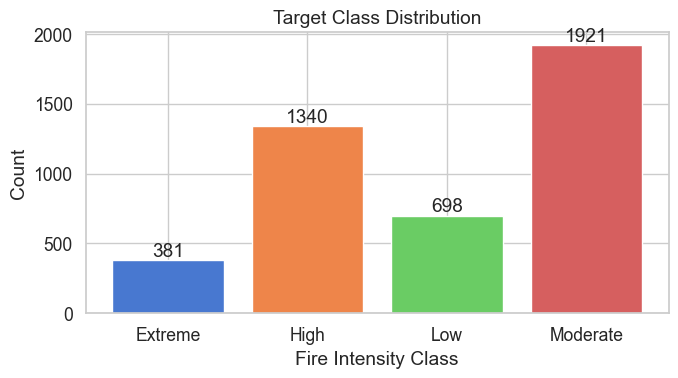

fire_intensity
Extreme      381
High        1340
Low          698
Moderate    1921
Name: count, dtype: int64


In [7]:
fig, ax = plt.subplots(figsize=(7, 4))
vc = df_tr['fire_intensity'].value_counts().sort_index()
bars = ax.bar(vc.index, vc.values, color=sns.color_palette('muted', 4))
ax.bar_label(bars, fmt='%d')
ax.set_title('Target Class Distribution')
ax.set_xlabel('Fire Intensity Class')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

print(vc)

The dataset is heavily skewed towards the 'Moderate' `fire_intensity` which accounts for about $45%$ of the total samples. Whereas the minority is shown to be fires of 'Extreme' intensity.

Due to the significant imbalance of classes, the metric **Accuracy** would be misleading. A naive model that over predicts the 'Moderate' class would noticably achieve a higher accuracy while failing to identify fires of the more high-risk class 'Extreme'.

In ensuring the model reliability in predicting across all fire intensities, **Macro F1-score** would be prioritized. This is due to Macro F1-score treating all classes with equal importance unlike a weighted F1-score.

### Missing values

In [8]:
missing = df_tr.isnull().sum()
missing_pct = (missing / len(df_tr) * 100).round(2)
mv = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(f'\nMissing value analysis\n')
print(mv[mv['Missing Count'] > 0])


Missing value analysis

              Missing Count  Missing %
month                   416       9.59
brightness_k            327       7.53
wind_max_kmh            207       4.77


The check above reveals 3 features with missing values: `month`, `brightness_k`, `wind_max_kmh`. None of the features have more than $10%$ of missing data, making them suitable for imputation.

*Numerical features (`brightness_k`, `wind_max_kmh`):*
> Both `brightness_k` and `wind_max_kmh` are prone to extreme outliers as well as environmental variables. Since the **Means** of these features are sensitive to those outliers, the **Median inputation** method is chosen. This would maintain the integrity of the data distribution by acting as a robust measure of central tendency.

*Categorical features (`month`):*
> `month`, a descrete variable represents a specific time period. If imputed with a non-integer mean, it would result in logical inconsistencies. Therefore, the **Mode imputation** method would be used to ensure the imputed values remain within the valid range of the feature `month`'s distribution.

### Numerical Feature Distribution

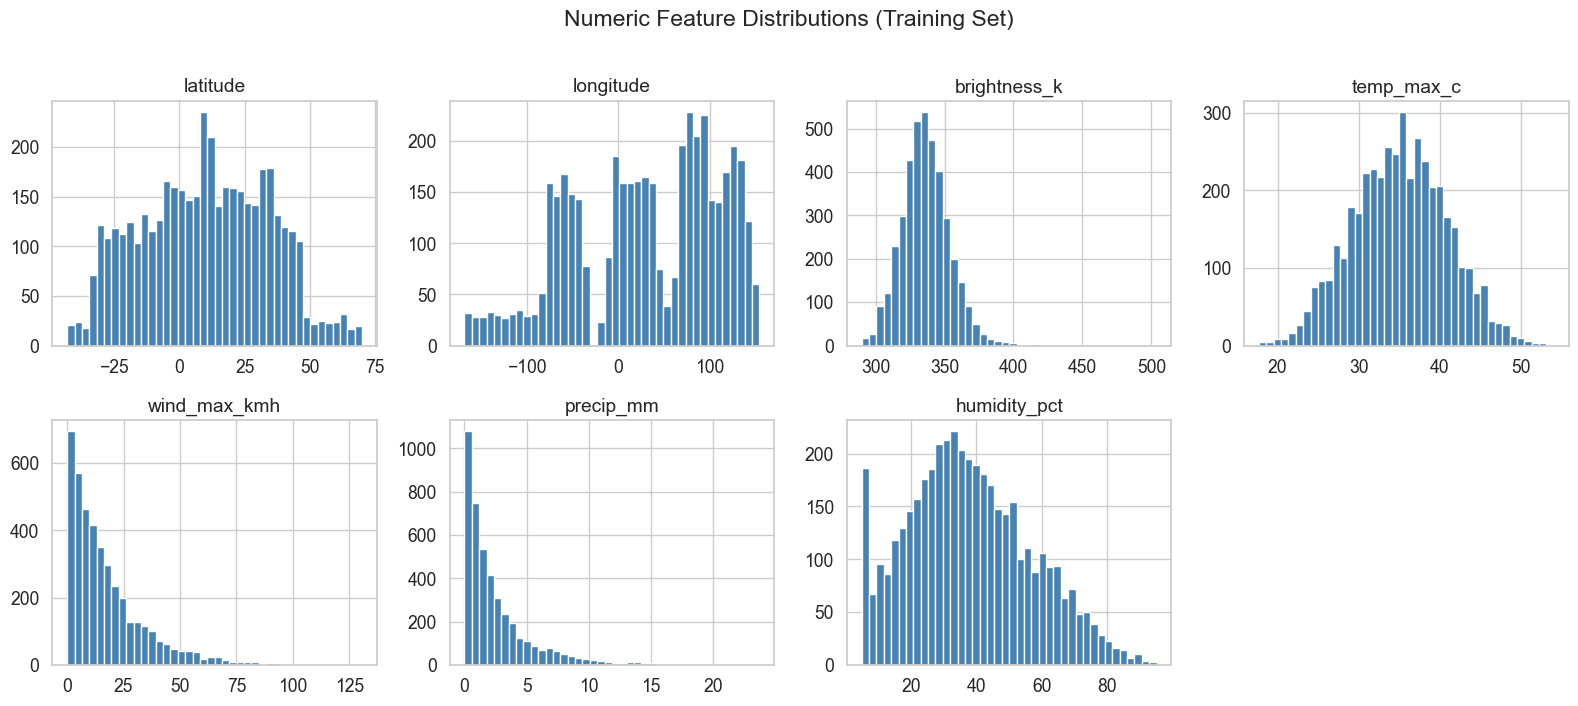

In [9]:
num_cols = ['latitude', 'longitude', 'brightness_k',
            'temp_max_c', 'wind_max_kmh', 'precip_mm', 'humidity_pct']

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    axes[i].hist(df_tr[col].dropna(), bins=40, color='steelblue', edgecolor='white')
    axes[i].set_title(col)
axes[-1].set_visible(False)
plt.suptitle('Numeric Feature Distributions (Training Set)', y=1.01)
plt.tight_layout()
plt.show()

The above numeric feature histogram and summary statistic inspection reveals two main characteristics that would influence the data preprocessing pipeline, which are **skewness**, and **variance of magnitudes**.

**Strong Right-skewness**:
> Features such as `wind_max_kmh`, and `precip_mm` show significant skewness to the right. The vast majority of the data are shown to be clustered at the lower end whereas the long tail represents the rarer, yet extreme weather events.

> Impact: Strongly skewed data could potentially obstruct models when converging. Even though **Decision Trees** are robust to this, **Neural nets** tend to prefer more symmetric input.

**Scale Disparity**:
>  A massive difference in numerical ranges across features is present. For example, `brightness_k`values are centered around the $340 K$ mark whereas `precip_mm` values are mostly below $5mm$.

> Impact: **SVM**s which use distance based kernels, and **Neural Nets** which use gradient optimization are considerably sensitive to these scales. If no measure was taken, the models would treat (mathematically) `brightness_k` as significantly more important than `precip_mm`, simply because the numbers are larger.

#### As mitigation to the identified issues:
Outlier-Robust Imputation: As previously discussed, the use of *median imputation* for missing values in `wind_max_kmh` and `brightness_k` is fully justified taking the above issues into consideration.

Feature Standardization: `StandardScalar` would be applied to all numerical features in the dataset. This transformation would shift the mean to $0$, scaling to unit variance (standard deviation of $1$). Ultimately, this measure ensures that SVMs and Neural Nets can efficiently converge without being biased by the presense of raw magnitudes as pointed out above.

### Numerical features vs Target (Box-plots)

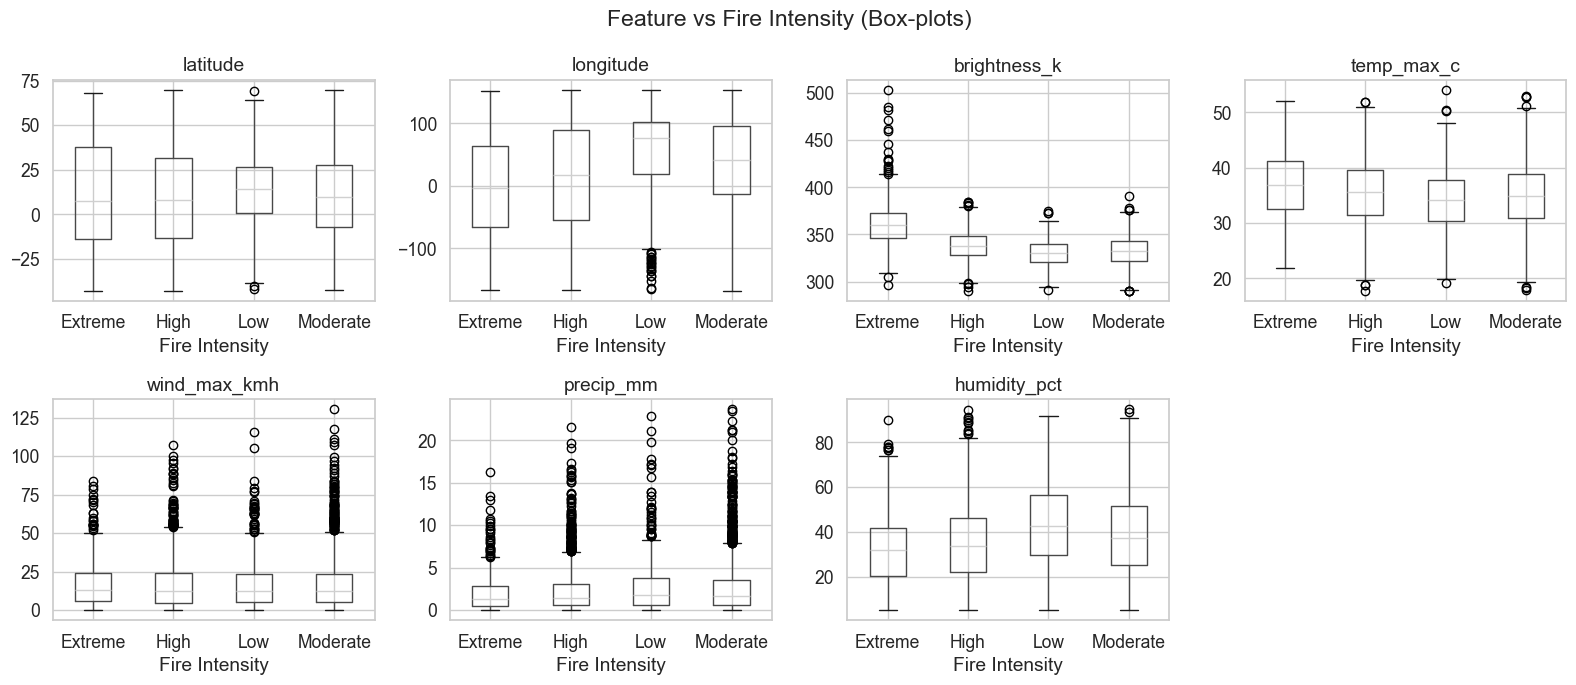

In [10]:
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    df_tr.boxplot(column=col, by='fire_intensity', ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_xlabel('Fire Intensity')
axes[-1].set_visible(False)
plt.suptitle('Feature vs Fire Intensity (Box-plots)')
plt.tight_layout()
plt.show()

# NOTE: The intensities go from Extreme -> High -> Low --then--> Moderate

To understand the discriminative properties of features for fire intensity classification, box-plots were generated for each numerical features across the intensity classes as above.

Important Observations:
> As the basic physics behind combustion suggests, `brightness_k` shows clear upward trend as intensity reaches the 'Extreme'. A significantly higher median brightness and a large number of higher value outliers are present in the 'Extreme' class, suggesting this would act as a primary predictor for the models.

> It is also important to note the behaviour of weather dynamics.
> - Looking at `temp_max_c`, higher fire intensity classes generally match with higher *max* air tempratures.
> - The inverse relationship of `humidity_pct` with intensity classes where it suggests higher intensity fires usually happen at lower humidity levels aligns with fire behaviour as dry fuel and air facilitate intense fires.

> The distribution of geographic coordinates (`logitude`/`latitude`) showcases a distict 'tightness' in some classes, hinting that fire intensity classes are very likely tied to certain climatic regions or types of fuel that can only be found in specific locations (logitudes/latitudes).

> Unlike other features , wind speed (`wind_max_kmh`) fail to show noticable differences in medians or interquartile range across the fire intensity classes. This leads to believe that `wind_max_kmh` is a noisy predictor. however, the significant outlier presense of all four classes, noticably 'High', 'Low', 'Moderate' classes reaching beyond $100 km/h$, indicates that even though wind influence fire bahaviour, it likely acts as a *secondary driver*.


After the above analysis, the clear seperation in `brightness_k`, and the overall clear and consistent trends in weather variables provide confirmation that the features contain sufficient enough signal for classification. The numeraous outlier presense in higher intensity classes strengthen the justification of using `StandardScalar` to normalise these distributions for the Neural Net and SVM, whereas the Decision Tree will natural handle the non-linear thresholds.

### Correlation Heatmap (Numerical Features)

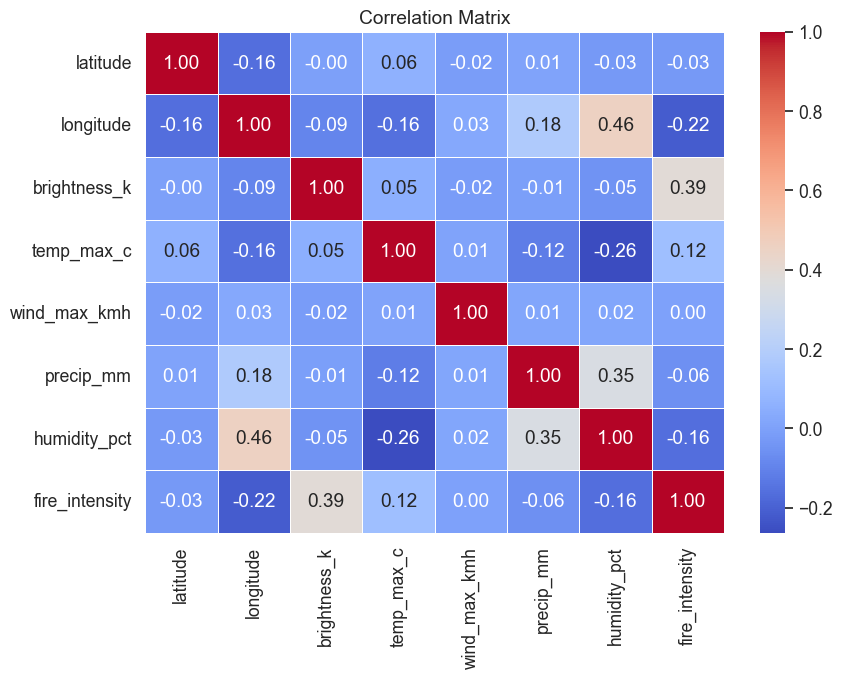

In [11]:
# map string labels to integers
label_map = {'Low': 0, 'Moderate': 1, 'High': 2, 'Extreme': 3}
df_tr['fire_intensity'] = df_tr['fire_intensity'].map(label_map).fillna(df_tr['fire_intensity']).astype(int)

corr = df_tr[num_cols + ['fire_intensity']].corr()
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', ax=ax, linewidths=0.5)
ax.set_title('Correlation Matrix')
plt.tight_layout()
plt.show()

A Pearson Correlation Matrix was generated to quantify the linear relationships present between numerical features and the target.

Identified **top predictors** for fire intensity:
1. `brightness_k` (0.39): This holds the stringest positive correlation. This is confirmation that brightness temprature is the most reliable linear predictor of the intensity of fire also aligning with the previous discoveries.
2. `longitude` (-0.22): This clear negative correlation indicates that, in this particular dataset, fires tend located to the further West, to be of higher intensity. Likely, this is due to regional climate patterns or vegetation types tied to those coordinates.
3. `humidity_pct` (-0.16): This negative correlation between humidity and fire intensity aligns with our previous findings, since lower moisture levels in air harbour more aggressive and intense fires.

Identified **multi-colinearity** observations:
- `humidity_pct` and `longitude` (0.46): This somewhat moderate of a positive correlation suggests that humidity levels are strongly tied to geographic locations in this dataset.
- `humidity_pct` and `precip_mm` (0.35): This showcases a rather logical relationship where higher precipitation correlates with higher humidity.
- `temp_max_c` and `humidity_pct` (-0.26): This is a very typical negative correlation (inverse relationship) found in weather data.

Impact on the Models:
> **Decision Trees**: These models generally tend to be immune to multi-colinearity, since they split on one single feature at a time. Therefore, correlations like the one between `humidity_pct` and `longitude` will not confuse the model (tree).

> **Neural Nets and SVMs**: These are the models that has the risk of being sensitive to high correlated features. With correlated features like `humidity_pct` and `longitude` move together at the same time, the SVM decision boundary has the potential of being less stable. However, since even the highest correlation of 0.46 is below the typical danger zone of 0.70 upward, all the features can be safely kept for the initial training phase.


An important thing to note is the **correlation between `fire_intensity` and `wind_max_kmh`**, where it is 0. This clearly align with what we discovered in the previous box-plot analysis, that wind speed is a *non-linear* factor.

### Categorical Feature Distributions

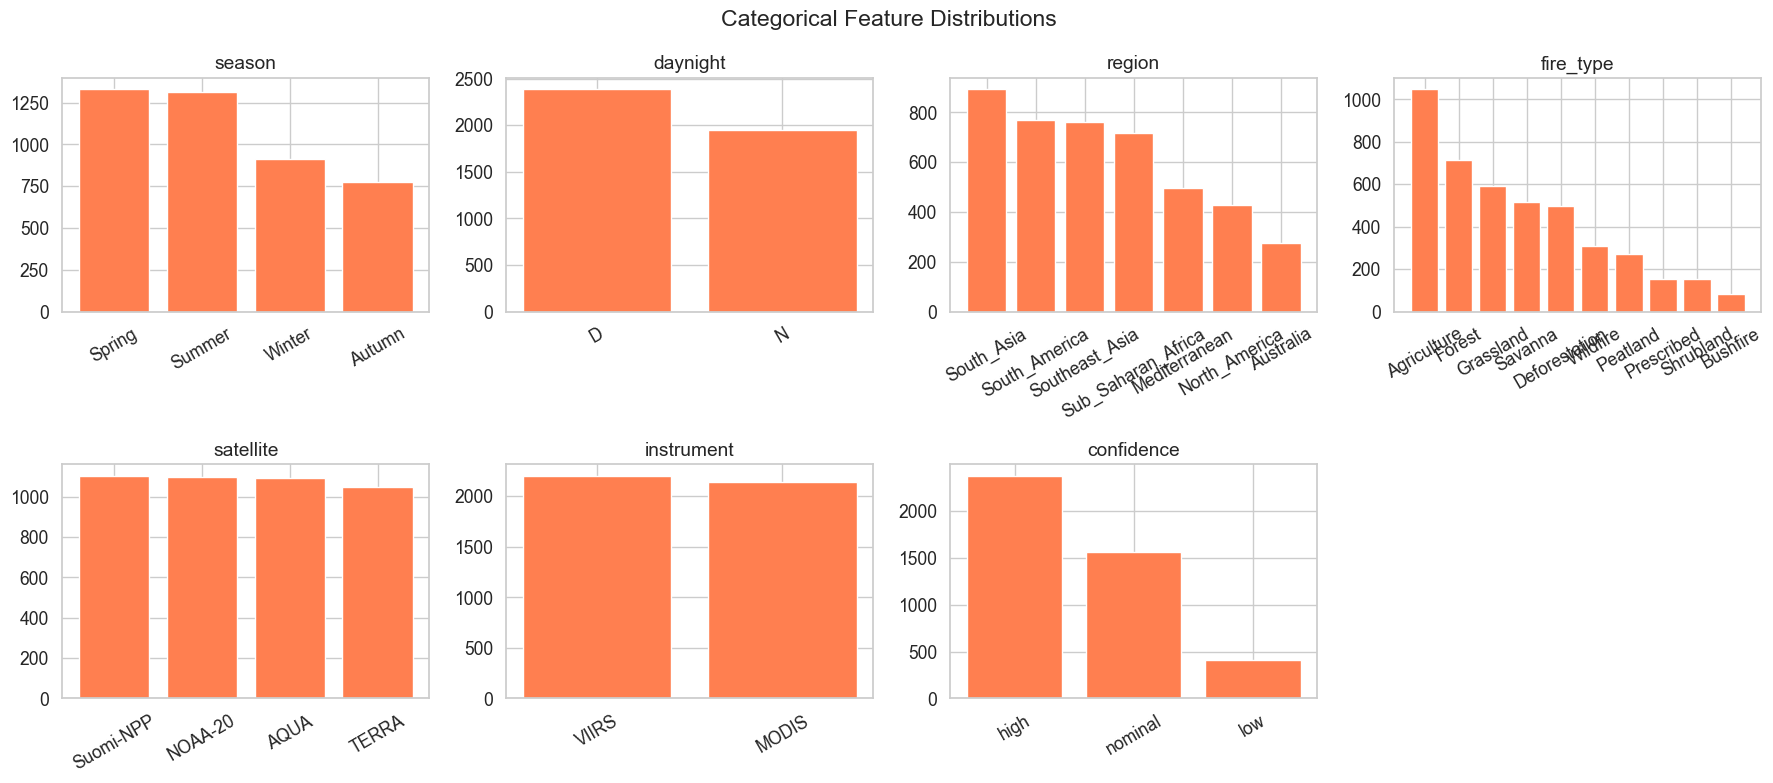

In [12]:
cat_cols = ['season', 'daynight', 'region', 'fire_type', 'satellite',
            'instrument', 'confidence']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
for i, col in enumerate(cat_cols):
    vc2 = df_tr[col].value_counts()
    axes[i].bar(vc2.index.astype(str), vc2.values, color='coral')
    axes[i].set_title(col)
    axes[i].tick_params(axis='x', rotation=30)
axes[-1].set_visible(False)
plt.suptitle('Categorical Feature Distributions')
plt.tight_layout()
plt.show()

The above categorical feature distributions showcase the environmental and operational context of the detections of wildfire.

Notable observations:
- Agriculture is the most frequent fire type by a considerable margin. This indicates that the models will be trained heavily on human manged fires. Categories like Bushfires, Shrubland are minority classes. Therefore, the models would have to rely on more features like humidity to differentiate naturally occuring fires from smaller agricultural fires.
- The findings also show a clear seasonal bias towards SPring and Summer, and a diurnal bias towards Daytime (D). Since wildfires happening during Autumn or Night (N) are sort of under represented, the models could be less reliable when when predicting off-season fires.
- The bulk of the data is from South Asia, and South Americal, etc whereas Australia provides the least. If the model were to be deployed in Australia, it's essential to be cautious of the regional bias.

## 2.3 Data Preprocessing

### Feature Selection

In [13]:
DROP_COLS = ['acq_date', 'acq_time']
TARGET    = 'fire_intensity'

# le_dict: label encoding dict.
def prepare_features(df, le_dict=None, fit=True):
    """
    Return X (features) and optionally y (target).
    le_dict: dict of LabelEncoders. If fit=True, create & fit; else reuse.
    """
    df = df.copy()
    df.drop(columns=[c for c in DROP_COLS if c in df.columns], inplace=True)

    # encode categorical columns
    cat_features = df.select_dtypes(include='object').columns.tolist()
    if TARGET in cat_features:
        cat_features.remove(TARGET)

    if le_dict is None:
        le_dict = {}

    for col in cat_features:
        if fit:
            le = LabelEncoder()
            df[col] = le.fit_transform(df[col].astype(str))
            le_dict[col] = le
        else:
            le = le_dict[col]
            # handle unseen labels
            df[col] = df[col].astype(str).map(
                lambda x, le=le: le.transform([x])[0]
                if x in le.classes_ else -1
            )

    if TARGET in df.columns:
        y = df.pop(TARGET).values
        return df, y, le_dict
    return df, le_dict


X_raw, y, le_dict = prepare_features(df_tr, fit=True)
X_test_raw, _    = prepare_features(df_te, le_dict=le_dict, fit=False)

print(f'Feature matrix shape : {X_raw.shape}')
print(f'Feature names        : {list(X_raw.columns)}')

Feature matrix shape : (4340, 17)
Feature names        : ['latitude', 'longitude', 'year', 'month', 'season', 'daynight', 'region', 'country', 'fire_type', 'satellite', 'instrument', 'brightness_k', 'confidence', 'temp_max_c', 'wind_max_kmh', 'precip_mm', 'humidity_pct']


##### Feature Pruning (Dropped Columns)
- `acq_data`: Since the temporal utility of this feature is already captured by `year` and `month`, keeping this raw string feature would ultimately add unnecessary complexity with no contribution.
- `acq_time`: This particular feature in its raw integer format is very misleading mathematically. A great example is, the difference between $2359$ and $0001$ is exactly $2$ minutes (in reality), but mathematically it's $2358$. Without any correct measure to indicate the reality of it, this feature acts more as noise than signal.

##### Label Encoding
The choice of using `LabelEncoder` for the categorical variables like `country` with 35 classes, `fire_type` with 10 classes, can be described as a strategic trade-off due to the following:
> Unlike with **one-hot encoding** where the dataset would be expanded by about 50 sparse columns, Label endcoding keeps the dataset compact making it very suitable for the Decision Tree, since it can find thresholds within numeric columns quite efficiently.
> 
> The important thing to note due to this is, that SVMs and Neural Nets could treat these arbitrary integers as an ordered list of numbers. For example, treating country no. 20 as greater than coutry no. 1. However, the regional signal provided by `country` justifies this compact representation of data as a starting point for baseline comparison.

##### Unseen Labels
To ensure that the `prepare_features()` function (or more specifically `LabelEncoder`) does not crash if the model were to encounter a new class that was not present in the training set, the above implementation includes a fallback trick where unseen categories in the test set would be mapped to $-1$.

### Impute Missing Values (For Numerical Features)

In [14]:
imputer = SimpleImputer(strategy='median')
X_imp       = imputer.fit_transform(X_raw)
X_test_imp  = imputer.transform(X_test_raw)

print(f'Any NaN after imputation (train) ? : {np.isnan(X_imp).any()}')
print(f'Any NaN after imputation (test) ? : {np.isnan(X_test_imp).any()}')

Any NaN after imputation (train) ? : False
Any NaN after imputation (test) ? : False


The **Medial Imputation** method was applied as previously justified during EDA. Additionally, it's important to note the following:
- `imputer.fit_transform` was used on the training set whereas `imputer.transform` was used on the test test. This measure prevents *Data Leakage*. The typical value is calculated based only the on the training data (the only data the model's allowed to see), and then applying the same rule for the test set. This imitates the real-world scenario of future data's median being unknown.
- The final `False` result confirms the absense of NaN values.

### Train/Validation Split

In [15]:
X_train, X_val, y_train, y_val = train_test_split(
    X_imp, y, test_size=0.20, random_state=SEED, stratify=y
)
print(f'Training   : {X_train.shape[0]:,} samples')
print(f'Validation : {X_val.shape[0]:,} samples')

Training   : 3,472 samples
Validation : 868 samples


To optimize the models' reliability in learning and evaluation, a *stratified $80/20$ split ($80%$ for training, $20%$ for validation)* was performed as above. Since stratification ensure that the split has the **exact same class propotions** in both training and validation sets, allowing the models to generalize across across all classes (e.g. fire levels).

### Feature Scaling

In [16]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc   = scaler.transform(X_val)
X_test_sc  = scaler.transform(X_test_imp)

print('Scaling done.')

Scaling done.


The above shows the application of `StandardScalar` to all numerical features as justified previously.

# 3.0 Model Development

## 3.1 Evaluation

In [17]:
def evaluate(model, X_tr, y_tr, X_v, y_v, label=''):
    """
    Prints and returns:
      - Accuracy (train & val)
      - Macro F1  (train & val): equal weight per class, primary metric
      - Weighted F1 (train & val): accounts for class frequency
      - Per-class F1 (val only): reveals weak classes
    """
    tr_pred = model.predict(X_tr)
    v_pred  = model.predict(X_v)

    tr_acc     = accuracy_score(y_tr, tr_pred)
    v_acc      = accuracy_score(y_v,  v_pred)
    tr_f1      = f1_score(y_tr, tr_pred, average='macro')
    v_f1       = f1_score(y_v,  v_pred,  average='macro')
    tr_wf1     = f1_score(y_tr, tr_pred, average='weighted')
    v_wf1      = f1_score(y_v,  v_pred,  average='weighted')
    per_class  = f1_score(y_v,  v_pred,  average=None)   # array of 4 values

    print(f'\n{"="*50}')
    print(f'  {label}')
    print(f'{"="*50}')
    print(f'  {"Metric":<20} {"Train":>8}  {"Val":>8}')
    print(f'  {"-"*38}')
    print(f'  {"Accuracy":<20} {tr_acc:>8.4f}  {v_acc:>8.4f}')
    print(f'  {"Macro F1":<20} {tr_f1:>8.4f}  {v_f1:>8.4f}')
    print(f'  {"Weighted F1":<20} {tr_wf1:>8.4f}  {v_wf1:>8.4f}')
    print(f'\n  Per-class F1 (val):')
    for i, score in enumerate(per_class):
        names = ['Low (0)', 'Moderate (1)', 'High (2)', 'Extreme (3)']
        print(f'    {names[i]:<15} {score:.4f}')

    return tr_acc, v_acc, tr_f1, v_f1, tr_wf1, v_wf1, per_class

#### Metrics Used:
The `evaluate()` function is built on a multi-metric approach, ensuring all the models are evaluated on the reliability they provide across different risk levels, not just speed and accuracy.

> - **Accuracy**: This metric provides a straightforward, quick, and a high-level baseline check.
> - **Macro F1-score**: This metric would serve as the primary benchmark. This metric, unlike accuracy which rewards models on guessing the majority 'moderate' class, handles each class with equal importance. This is especially important to note, since failing to predict an 'Extreme' fire is massively dangerous than mislabeling a 'Moderate' (most common class in the dataset) fire. Macro F1 makes sure that the model gets penalized cosiderably in the events of ignoring rarer and more impactful fires.
> - **Weighted F1-score**: This metric differs from Macro F1-score which evaluates each class equally (exactly 25% for this dataset), by adjusting each class's contribtion based on the frequency of that class in the *dataset*. Ultimately, this produces an evaluation that conveys the overall quality of the predictions while also taking into account that some classes may happen more commonly.
> - **Per-class F1-score**: This is a broken-down version of the F1-score for each class (Low, Moderate, High, Extreme), making it easier to diagnose specific weaknesses. This metric would allows us to identify the models' confusions (if present) between similar fire intensities (e.g., High vs Extreme), or another case is the models' blind spots for specific classes.


#### Metric Not Used:
> - **MSE/MAE/RMSE**: These two metrics are excluded since they are primarily used for evaluating regression tasks. This would treat fire intensity as a continuous number implying that the difference between 'Moderate' and 'High' is the same as 'High' and 'Extreme', completely defying the classification boundaries.

In [18]:
def plot_confusion(model, X_v, y_v, title='Confusion Matrix'):
    cm = confusion_matrix(y_v, model.predict(X_v))
    disp = ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES)
    fig, ax = plt.subplots(figsize=(7, 6))
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

The `plot_confusion()` function is used for visualizing the patterns of Errors for a model through a confusion matrix.

In [19]:
def hyperparam_curve(param_vals, tr_scores, val_scores, xlabel, title, log=False):
    fig, ax = plt.subplots(figsize=FIGSIZE)
    ax.plot(param_vals, tr_scores,  'o-', label='Train')
    ax.plot(param_vals, val_scores, 's--', label='Validation')
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Macro F1')
    ax.set_title(title)
    if log:
        ax.set_xscale('log')
    ax.legend()
    plt.tight_layout()
    plt.show()

The `hyperparam_curve()` function plots training and validation performances across values for a specific hyper paramter. This is the visualization of bias variance trade-off.

## 3.2 Model 1: Decision Tree

The feature space is partitioned by the Decision Tree into a axis parallel hyper-rectangle series by selecting the feature and split point recursively, so that the Information Gain is maximized. The Gini Impurity ($G$) minimized split is identified at each node to move forward.
$$G=1-\sum_{i=1}^{K}p_i^2$$
Where $p_i$ is the probability of a sample belonging to class $i$ in $K$ classes in total. This model can be defined as the **Non-linear Baseline** for this task, as it is non-paramteric and captures non-linear relationships without feature scaling. The model's performance would ultimately set the benchmark for the more complex models yet to come, which are SVM and Neural Net.

It is also important to note the primary vulnerabilities of Decision Trees which are high variance and overfitting as the algorithm has a quality of being greedy. And as the model's main goal is to minimize the overall impurity, it can be biased towards the major class ('Moderate' in this dataset).

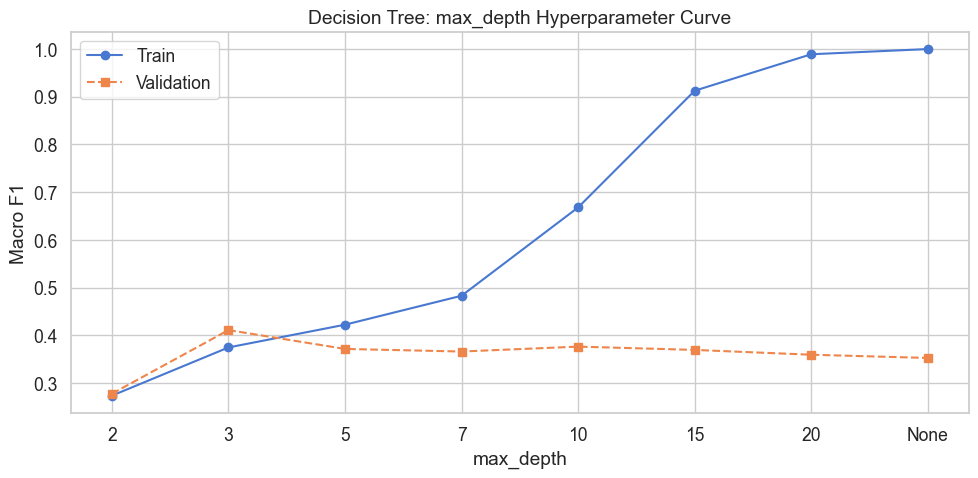

Best max_depth (by val Macro-F1): 3


In [20]:
# hyperparam 1: max_depth
depths       = [2, 3, 5, 7, 10, 15, 20, None]
depth_labels = [str(d) if d else 'None' for d in depths]
tr_f1s, val_f1s = [], []

for d in depths:
    dt = DecisionTreeClassifier(max_depth=d, random_state=SEED)
    dt.fit(X_train, y_train)
    tr_f1s.append(f1_score(y_train, dt.predict(X_train), average='macro'))
    val_f1s.append(f1_score(y_val,  dt.predict(X_val),  average='macro'))

fig, ax = plt.subplots(figsize=FIGSIZE)
x_pos = range(len(depths))
ax.plot(x_pos, tr_f1s, 'o-', label='Train')
ax.plot(x_pos, val_f1s, 's--', label='Validation')
ax.set_xticks(x_pos)
ax.set_xticklabels(depth_labels)
ax.set_xlabel('max_depth')
ax.set_ylabel('Macro F1')
ax.set_title('Decision Tree: max_depth Hyperparameter Curve')
ax.legend()
plt.tight_layout()
plt.show()

best_depth = depths[int(np.argmax(val_f1s))]
print(f'Best max_depth (by val Macro-F1): {best_depth}')

#### Decision Tree Optimization: `max_depth` analysis
The `max_depth` parameter was evaluated to find the optimal complexity of the model. Three distinct phases of the Decision Tree's behaviour is notable:
> 1. Underfitting: At the lowest depths (2), both the Macro F1-score (training and validation) are low. This is due to the Tree not being complex enough to capture the patterns lying beneath the wildfire data. The model fails to identify differences between intensities as it makes overly broad generalizations.
> 2. Sweet Spot: At depth $3$, the validation score comes to the peak. This shows that at this point, the Tree has learned to generalize well enough to unseen data without getting distracted by noise. This is essentially the optimal balance where the model is complex enough for use, and simple enough for robustness.
> 3. Overfitting: A massive divergence occurs as the `max_depth` increases towards `None` (Training Macro F1-score climbs up to $1$). Validation F1 stablizes and starts to degrade. At this point, the Tree is memorizing the training data including all its specific noise as well as outliers. This type of model has no real value or use in the real world.

Therefore, the 'Sweet Spot' of `max_depth`$=3$ is chosen to go forward.

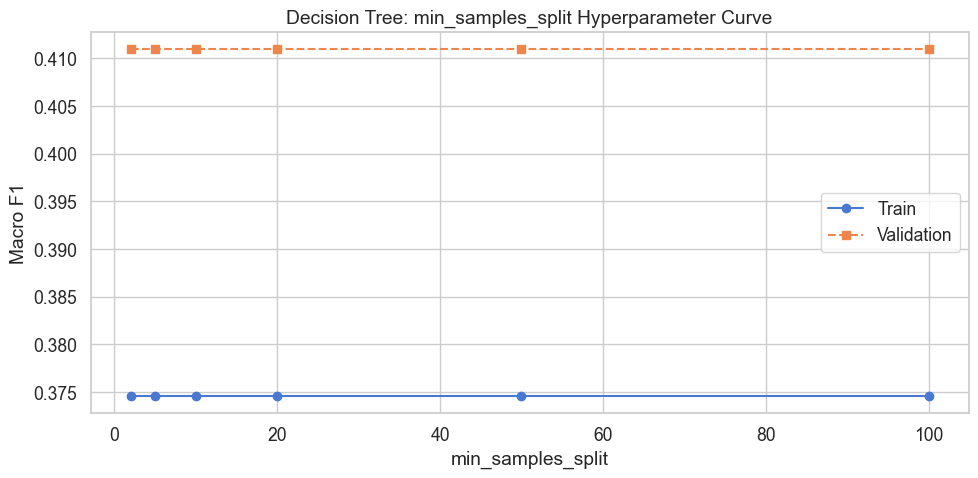

Best min_samples_split: 2


In [21]:
# hyperparam 2: min_samples_split
min_splits   = [2, 5, 10, 20, 50, 100]
tr_f1s2, val_f1s2 = [], []

for ms in min_splits:
    dt_tmp = DecisionTreeClassifier(
        max_depth=best_depth, min_samples_split=ms, random_state=SEED
    )
    dt_tmp.fit(X_train, y_train)
    tr_f1s2.append(f1_score(y_train, dt_tmp.predict(X_train), average='macro'))
    val_f1s2.append(f1_score(y_val,  dt_tmp.predict(X_val),  average='macro'))

hyperparam_curve(min_splits, tr_f1s2, val_f1s2,
                 'min_samples_split',
                 'Decision Tree: min_samples_split Hyperparameter Curve')

best_mss = min_splits[int(np.argmax(val_f1s2))]
print(f'Best min_samples_split: {best_mss}')

#### Decision Tree Optimization: `min_sample_split` analysis
`min_sample_split` parameter was tested to know if the model could be further refined through requiring a minimum number of samples to trigger a node split.

The above results shows completely flat lines for both training and validation scores across the tested values of $2$ to $100$. This indicates that the `min_sample_split` parameter does not affect the final Tree structure, for this specific dataset and a final `max_depth` of $3$. Since the Tree was limited to a shallow depth of $3$, the nodes reach the end of their depth before running out of samples.

If `max_depth` was set on a larger value (e.g., 15 or more), the parameter `min_sample_split` would have had a noticable regularization effect. This would have also prevented the Tree from creating small, overfit leaves deeper into the Tree.

As increasing the `min_samples_split` does not have a positive effect on generalization or the model's behavior, the `min_sample_split` would be fixed at the default value of 2. This ensures the model's logic is kept simple while relying on the primary defense against overfitting `max_depth`.


  Decision Tree (Best)
  Metric                  Train       Val
  --------------------------------------
  Accuracy               0.4827    0.4988
  Macro F1               0.3746    0.4110
  Weighted F1            0.4361    0.4543

  Per-class F1 (val):
    Low (0)         0.0000
    Moderate (1)    0.5809
    High (2)        0.4710
    Extreme (3)     0.5920

Classification Report (Validation):
              precision    recall  f1-score   support

     Low (0)       0.00      0.00      0.00       140
Moderate (1)       0.51      0.68      0.58       384
    High (2)       0.45      0.50      0.47       268
 Extreme (3)       0.76      0.49      0.59        76

    accuracy                           0.50       868
   macro avg       0.43      0.42      0.41       868
weighted avg       0.43      0.50      0.45       868



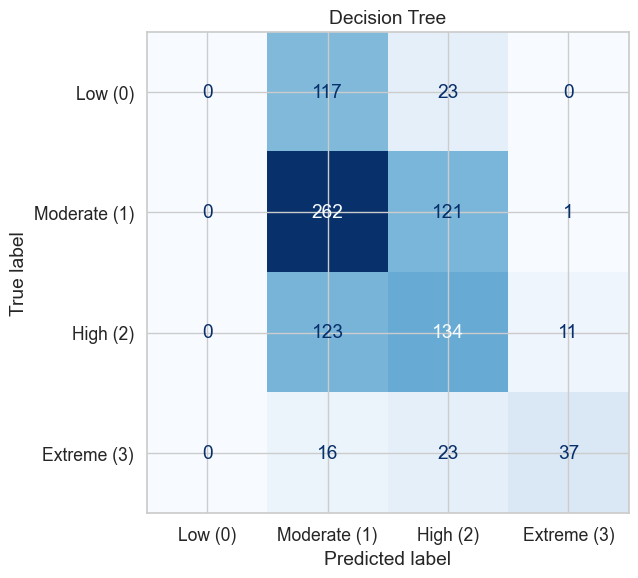

In [22]:
# final Decision Tree model
dt_best = DecisionTreeClassifier(
    max_depth=best_depth,
    min_samples_split=best_mss,
    random_state=SEED
)
dt_best.fit(X_train, y_train)

dt_tr_acc, dt_val_acc, dt_tr_f1, dt_val_f1, dt_tr_wf1, dt_val_wf1, dt_per_class = evaluate(
    dt_best, X_train, y_train, X_val, y_val, label='Decision Tree (Best)'
)

print('\nClassification Report (Validation):')
print(classification_report(y_val, dt_best.predict(X_val), target_names=CLASS_NAMES))
plot_confusion(dt_best, X_val, y_val, 'Decision Tree')

### Performance and Behavior Analysis
The baseline Decision Tree model showcases a stable yet limited predictive capacity, as indicated by the covergence of training ($0.4827$) and validation ($0.4988$) accuracy.

#### Quantitative Analysis
> - Macro F1($0.4110$) vs Weighted F1($0.4543$): The divergence between these two metric as shown above indicates that the model is performing disprportionately well on the 'Moderate' class which is the majority while struggling due to class imbalance. 

> - Anomaly of the 'Extreme' class: The model has achieved its highest precision of $0.76$ here, despite the fact that the 'Extreme' class is a minority with just $76$ labels. The showcases that the Decision Tree model was successful in identifying a strong signal for more dangerous fires that differenciate themselves from lower intensty fires.

#### Visualization and Behavioural Diagnostics
> - 'Low' class colapse: The confusion matrix reveals the total failure of the model predicting low intensity fires (F1-socre$=0.0$). This happens because the Tree model is limited to a `max_depth` of $3$ and therefore, its priority is to chose a split that reduce the most Gini Impurity. As 'Low' and 'Moderate' fires most likely share somewhat similar atmospheric features and characteristics, the Decision Tree being a greedy algorithm decides to classify these samples into the 'Moderate' majority as the most mathematically efficient path.
> - Misclassification: A massive portion of 'High' class fires are classified as fires of 'Moderate' intensity. This indicates a central tendency bias, where the Tree's shallow depth push it to favor the middle of the distribution preventing the model from exploring the nuances at the boundaries.

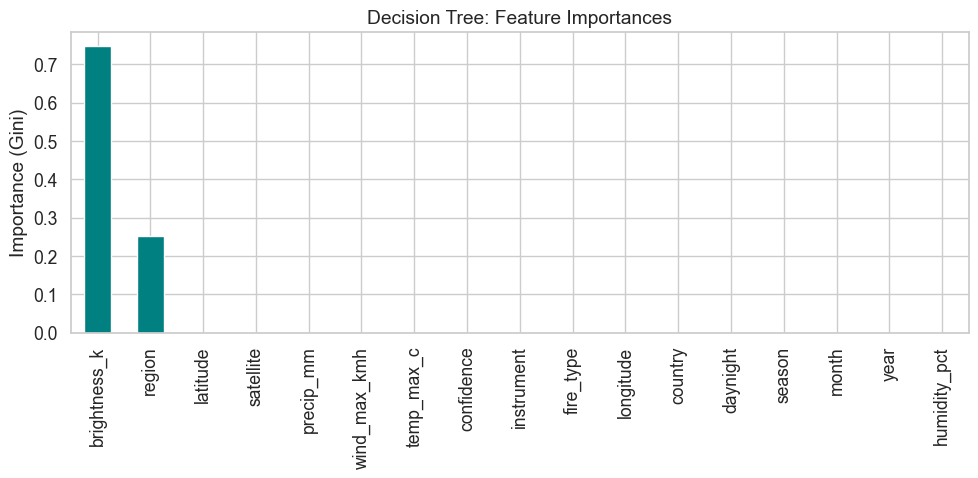

In [23]:
# feature importance
feat_names = X_raw.columns.tolist()
importances = pd.Series(dt_best.feature_importances_, index=feat_names)
importances = importances.sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
importances.plot.bar(ax=ax, color='teal')
ax.set_title('Decision Tree: Feature Importances')
ax.set_ylabel('Importance (Gini)')
plt.tight_layout()
plt.show()

### Feature Importance
The above feature importance plot shows that the model's logis is depenedent entirely on two variables:
> - `brightness_k`: This feature acts as the primary driver, holding about $75%$ of the relative importance. This thermal feature is the key engine for the highly precise 'Extreme' fire predictions. The tree (likely) creates a threshold split where if `brightness_k` is above a certain kelvin measure, it is labelled 'Extreme'.
> - `region`: This feature provides the spatial context and aid required to define the 'Moderate' vs 'High' bounds acting as the secondary driver.

All the other features have $0$ importance as the tree ignores these features due to the greedy nature of the algorithm.

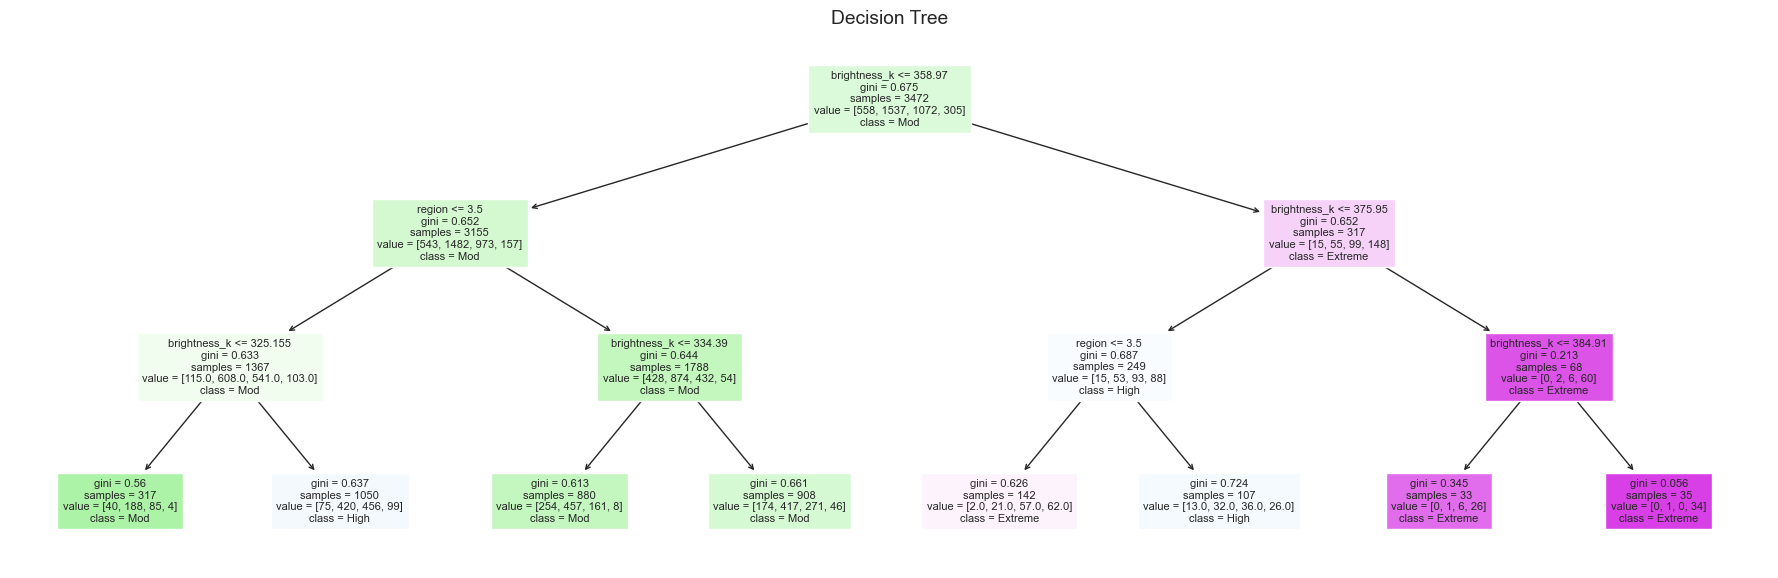

In [24]:
fig, ax = plt.subplots(figsize=(18, 6))
plot_tree(dt_best, max_depth=3, feature_names=feat_names,
          class_names=['Low','Mod','High','Extreme'],
          filled=True, ax=ax, fontsize=8)
ax.set_title('Decision Tree')
plt.tight_layout()
plt.show()

## 3.3 Model 2: Support Vector Machine (SVM)

The Support Vector Machines are margin based, robust classifiers that's objective is to find the optimal hyperplane that group classes in higher dimensional feature spaces. The SVM creates a decision boundary by maximizing the *margin* which s the distance between the hyperplane and the closest data points of each class, also knows as support vectors.

The objective is the following:
$$\min_{w,b, \xi} \frac{1}{2} \|w\|^2 + C \sum_{i=1}^{n} \xi_i$$

where $C$ is the regularization parameter and $\phi(x)$ is a mapping into a high dimensional space. The SVM has the ability to identify complex, non-linear decision boundaries that aren't visible in the original feature space (2D, 3D). This is achieved by utilizing the kernel trick, typically the Radial Basis Function Kernal.

The primary vuerabilities of SVMs are:
> - Sensitivity towrads Scaling: As SVMs are distance based models, if for example, `brightness_k` feature is not properly scaled relative to `precip_mm`, the model will entirely be biased toward the numbers larger in magnitude. As this problem was identified previously, it was also attended by applying Standardization.
> - Imbalance of Classes: As the standard SVMs' aim is to maximize the total margin, the hyperplane could be pushed toward the minority classes like 'Extreme' and 'Low' by just the volume of the 'Moderate' class in the imbalanced case.

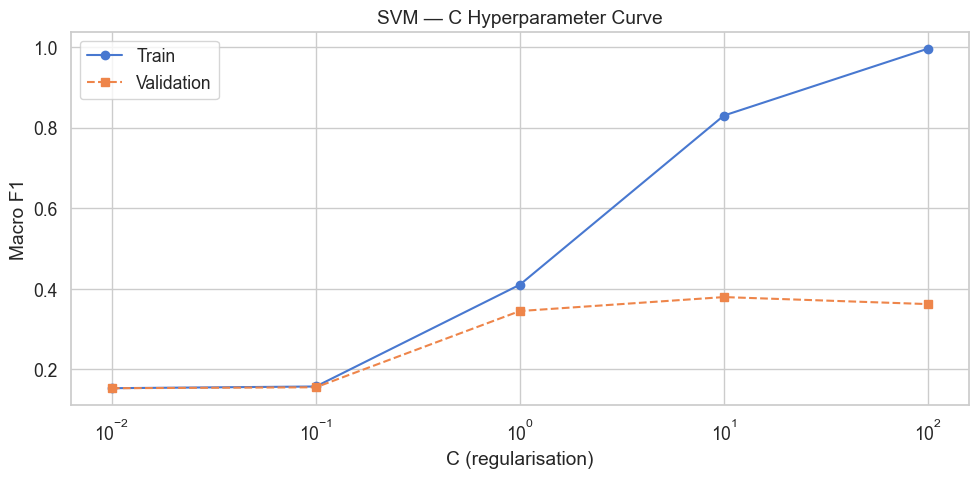

Best C: 10


In [25]:
# Hyperparameter 1: C (regularisation)
C_values = [0.01, 0.1, 1, 10, 100]
tr_f1s_svm, val_f1s_svm = [], []

for C in C_values:
    svm_tmp = SVC(C=C, kernel='rbf', gamma='scale', random_state=SEED)
    svm_tmp.fit(X_train_sc, y_train)
    tr_f1s_svm.append(f1_score(y_train, svm_tmp.predict(X_train_sc), average='macro'))
    val_f1s_svm.append(f1_score(y_val,  svm_tmp.predict(X_val_sc),  average='macro'))

hyperparam_curve(C_values, tr_f1s_svm, val_f1s_svm,
                 'C (regularisation)', 'SVM — C Hyperparameter Curve', log=True)

best_C = C_values[int(np.argmax(val_f1s_svm))]
print(f'Best C: {best_C}')

### SVM Optimization: `C`(regularization) Parameter Analysis
The regularization paramter $C$ is in control of the trade-off between achieving minimal training error and maximizing the margin of the decision boundary at the same time. In the above experiment, $C$ was varied across four orders of magnitude from $10^{-2}$ to $10^2$.

> 1. **Underfitting**: At the lowest of the $C$ values, the misclassification penalty is negligible. The major priority of the model at this time is the large margin. This results in a decision boundary that however cannot capture the underlying structure of the wildfire data due to its (the model's) simplicity. The extremely low Macro F1-scores indicate exactly this, where the model is very likely to default to the 'Moderate' class for all predictions as it's the majority class.
> 2. **The Sweet Spot**: The validation score reaches its own peak at $C=1$. This is where the SVM has reached its optimal balance where it's strict enough to create complex boundaries that also respect the different intensity classes but at the same time lenient enough, so the model ignores noise and outliers. Ultimately, this produces the best generalisation on unseen data.
> 3. **Overfitting**: A sharp divergence is present where training F1-score reaches a perfect $1$ and the validation F1-score starts to decline (slightly) as $C$ increases to $100$. This behavior can be exaplained as a higher $C$ imposes a huge penalty for misclassifications in the training set, and to avoid these penalties, the SVM transforms the decision boundary into a newer, highly complex structure catching every single data point including the outliers present. This leaves us with a model that perfectly predicts the training data but fails when met with different distributions in the validation dataset.

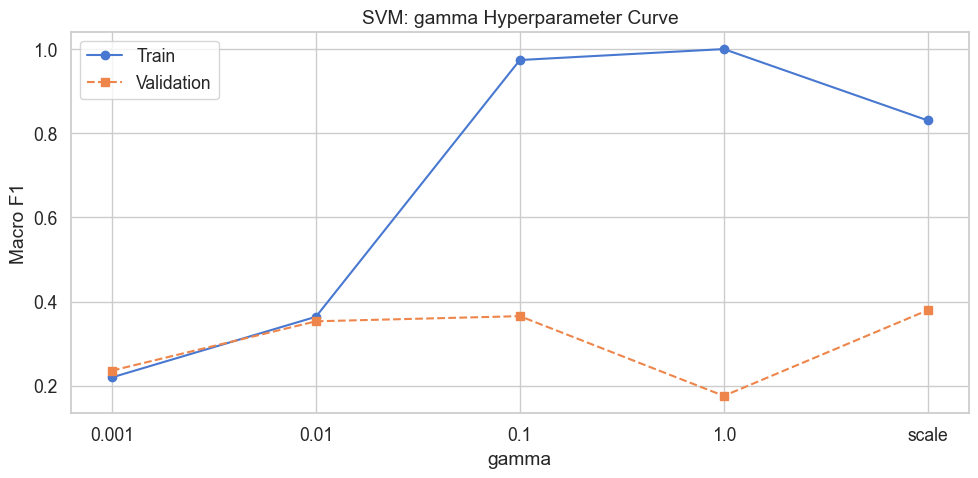

Best gamma: scale


In [26]:
# Hyperparameter 2: gamma
gamma_vals = [0.001, 0.01, 0.1, 1.0, 'scale']
tr_f1s_g, val_f1s_g = [], []

for g in gamma_vals:
    svm_g = SVC(C=best_C, kernel='rbf', gamma=g, random_state=SEED)
    svm_g.fit(X_train_sc, y_train)
    tr_f1s_g.append(f1_score(y_train, svm_g.predict(X_train_sc), average='macro'))
    val_f1s_g.append(f1_score(y_val,  svm_g.predict(X_val_sc),  average='macro'))

x_pos = range(len(gamma_vals))
fig, ax = plt.subplots(figsize=FIGSIZE)
ax.plot(x_pos, tr_f1s_g,  'o-', label='Train')
ax.plot(x_pos, val_f1s_g, 's--', label='Validation')
ax.set_xticks(x_pos)
ax.set_xticklabels([str(g) for g in gamma_vals])
ax.set_xlabel('gamma')
ax.set_ylabel('Macro F1')
ax.set_title('SVM: gamma Hyperparameter Curve')
ax.legend()
plt.tight_layout()
plt.show()

best_gamma = gamma_vals[int(np.argmax(val_f1s_g))]
print(f'Best gamma: {best_gamma}')

### SVM Optimization: Kernal Coefficient ($\gamma$)
The parameter $\gamma$ defines the reach of a single training example in the RBF (Redial Basis Function) Kernal:
$$K(x, x') = \exp(-\gamma \|x - x'\|^2)$$

> 1. At the lowest of the $\gamma$ values, each point's influence extends across the feature space very far, as the kernal has a larger radius. This results in a decision boundary that is incapable of capturing local clusters of the fire data as the boundary is overly smooth. Ultimately, the model underperforms on both the training and validation data as it is in a state of high bias.
> 2. **Overfitting**: A significant collapse of the curve at $\gamma=1$ is shown above. The trainig F1-score hits a perfect $1$. The validation F1-score goes down to its lowest point at about $0.15$. This behaviour can be explained as follows. As the $\gamma$ value peaks, the reach of each training point becomes very localized. This results in the model creating tiny round boundaries around every single data point in the training set individually (this is known as 'spiking'). Although, this leads the model to acheive the perfect training performance, the model is incapable of classifying anything that doesn't sit exactly on a training point, resulting in failure on the validation set.
> 3. The heuristic `scale` ($1 / (n_{features} \times X.var())$) is shown to have provided the best performance of Macro F1-score of about $0.37$. This heuristic automatically adjusts the kernel's radius based on the standardized feature distribution, ultimately preventing the 'spiking' phenomenon seen at higher values of $\gamma$. This is done while maintaining the complexity of the model to outperform the low gamma ($\gamma$) models.


  SVM (Best)
  Metric                  Train       Val
  --------------------------------------
  Accuracy               0.8361    0.4332
  Macro F1               0.8304    0.3797
  Weighted F1            0.8342    0.4229

  Per-class F1 (val):
    Low (0)         0.2058
    Moderate (1)    0.5392
    High (2)        0.3769
    Extreme (3)     0.3969

Classification Report (Validation):
              precision    recall  f1-score   support

     Low (0)       0.24      0.18      0.21       140
Moderate (1)       0.50      0.59      0.54       384
    High (2)       0.39      0.37      0.38       268
 Extreme (3)       0.47      0.34      0.40        76

    accuracy                           0.43       868
   macro avg       0.40      0.37      0.38       868
weighted avg       0.42      0.43      0.42       868



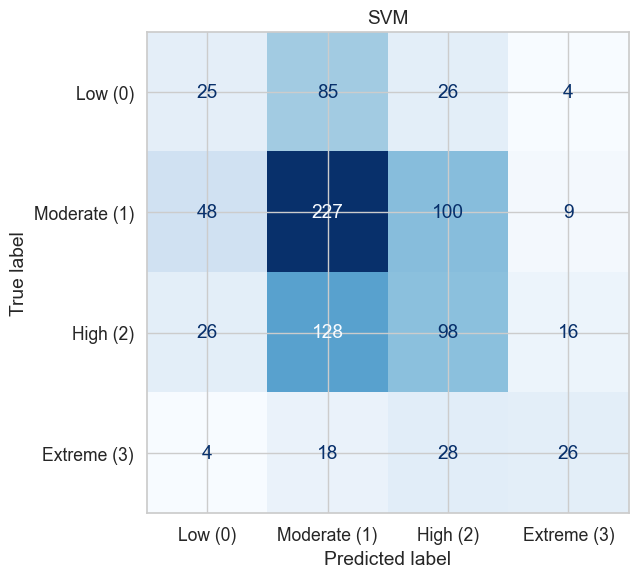

In [27]:
# Final SVM model
svm_best = SVC(C=best_C, kernel='rbf', gamma=best_gamma, random_state=SEED)
svm_best.fit(X_train_sc, y_train)

svm_tr_acc, svm_val_acc, svm_tr_f1, svm_val_f1, svm_tr_wf1, svm_val_wf1, svm_per_class = evaluate(
    svm_best, X_train_sc, y_train, X_val_sc, y_val, label='SVM (Best)'
)

print('\nClassification Report (Validation):')
print(classification_report(y_val, svm_best.predict(X_val_sc), target_names=CLASS_NAMES))
plot_confusion(svm_best, X_val_sc, y_val, 'SVM')

### Performance and Behavior Analysis
#### Quantitative Performance:
The optmized SVM of $C=10$ and $\gamma=$`scale` has achieved a validation Macro F1-score of $0.3797$ and an Accuracy of $43.32%$. Even though the metrics suggest somewhat moderate predictive power, the model's internal behavior suggests a signigicant discrepancy between its abilities on training and validation.

> - **The Gap of generalization**: The model has achieved a training Macro F1-score of $0.8304$, compared to the validation Macro F1-score of $0.3797$. This significant difference of about $45%$ indicates a high variance state. The SVM is very likely overfitting to the specific thermal and spatial coordinates of the training set, ignoring the generalization fire intensty rules.
> - **Weighted vs Macro F1-scores**: The difference between the Weighted F1 ($0.4229$) and Macro F1 ($0.3797$) as the Weighted F1 is higher, shows that the model is reliable and effective at classifying the majority of 'Moderate' class than rarer intensity levels such as 'Low', 'Extreme'.

#### Behavior Analysis and Class Distribution:
A diagnostic view of the SVM's behavior on fire intensity boundaries was provided by the confusion matrix:
> - **Diversity Success**: This SVM model differs itself from simpler models by successfully identifying occurances of 'Low' intensity fires with a Per-class F1-score of $0.2058$. The confusion matrix above also confirms that the SVM correctly identified $25$ 'Low' class samples, showcasing that the RBF Kernel's high dimensional mapping can indeed find seperation that linear or greedy models like Decision Trees miss.
> - **Boundary Ambiguity**: There's significant leakage between adjacent classes present. For example, $85$ of 'Low' intensity fires were misclassified as 'Moderate', and $128$ 'High' intensity fires were misclassified as 'Moderate', suggesting that the distance-based logic of the SVM model noticably struggles with distributions of overlapping features such as thermal signatures and humidity that occur at the transitions between levels of intensity.
> - **'Extreme' Class Performance**: The model was able to maintain a moderate Per-class F1-score of $0.3969$ for fires of fires of 'Extreme' intensity. However, the model fails to identify $66%$ of the actual 'Extreme' events in the validation dataset.

## 3.4 Model 3: Neural Network (MLP)

The Multi-Layer Perceptron or an MLP is a feedforward, artificial neural network that maps input features of a dataset to classes of fire intensity through a serial, non-linear transformation. The MLP netwok is an architecture of interconnected neurones organized into multiple layers such as input, hidden, and output layers. Each and every neuron calculates a weighted sum if its input $x$ and a bias $b$ term ($z = \sum w_i x_i + b$) and then passes this result through an activation function like ReLU to introduce non-linearity. The model is optimized using an algorithm like Adam which updates the weights $w$ via Backpropagation to achive the minimal loss (cross-entropy loss). The mentioned learning process is built on the below weight update rule:
$$w_{t+1} = w_t - \eta \frac{\partial L}{\partial w_t}$$

where $\eta$ is the learning rate and $L$ is the loss function. Through this, the network can synthesize information from all 17 features simultaneously, capturing interactions between atmospheric conditions and thermal signatures that simple model usually overlook.

It is also important to note the primary vulnerabilities of MLPs are.
> - Overfitting on small datasets: Due to MLPs being higher in capacity, it is very prone to memorizing noise and outliers during training.
> - Hyperparameter sensitivity: The MLP models tend to be very dependent on the initial learning rate. This is due to optimization divergence and thus, a total collapse in predictive performance which can happen if the learning rate or the step size were to be too large. If the learning rate was to be too small, this could result the learning process running out of iterations as the model takes too small of steps to converge. Therefore, finding a suitable learning rate is mandatory.

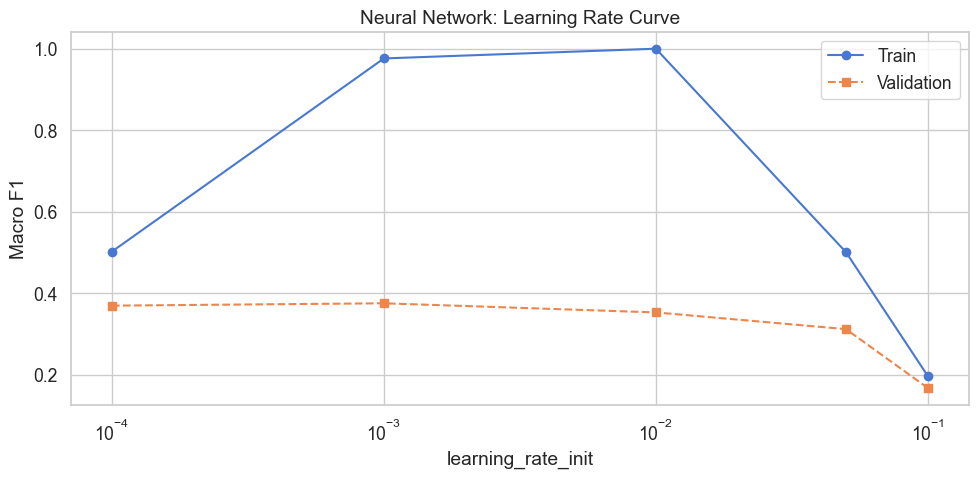

Best learning_rate_init: 0.001


In [28]:
# Hyperparameter 1: learning_rate_init
lr_vals = [0.0001, 0.001, 0.01, 0.05, 0.1]
tr_f1s_nn, val_f1s_nn = [], []
loss_curves = {}

for lr in lr_vals:
    mlp_tmp = MLPClassifier(
        hidden_layer_sizes=(128, 64),
        learning_rate_init=lr,
        max_iter=200,
        random_state=SEED,
        early_stopping=False,
        solver='adam'
    )
    mlp_tmp.fit(X_train_sc, y_train)
    tr_f1s_nn.append(f1_score(y_train, mlp_tmp.predict(X_train_sc), average='macro'))
    val_f1s_nn.append(f1_score(y_val,  mlp_tmp.predict(X_val_sc),  average='macro'))
    loss_curves[lr] = mlp_tmp.loss_curve_

hyperparam_curve(lr_vals, tr_f1s_nn, val_f1s_nn,
                 'learning_rate_init', 'Neural Network: Learning Rate Curve', log=True)

best_lr = lr_vals[int(np.argmax(val_f1s_nn))]
print(f'Best learning_rate_init: {best_lr}')

### Neural Net Optimization: Learning Rate $\eta$ Analysis
#### Training Dynamics and Convergence

> - **Overfitting**: From $10^{-3}$ to $10^{-2}$, the model achieves almost perfect performance in training with Macro F1-score at $\approx 1.0$. This indicates that the Adam Solver is efficient in navigating the loss landscape and discovering a global minimum for the training data. Despite this, the validation F1-score remains flat at $0.38$, showcasing that the better training accuracy does to translate to better generalization.
> - **Failure to Converge**: At a high learning rate $\eta$ of $0.1$, the performances of both training and validation collapse. This is because the step size being too large, causing weights to overshoot the optimal minima and oscillate or just diverge.
> - **Slow Learning**: At the learning rate of $0.0001$, the model noticably underperforms since it has not reach convergence within the given 200 iterations, as the step size is too little.
> - **Sweet Spot**: At the learning rate $\eta$ of $0.001$, the model is shown to achieve its highest validation score, as well as a higher training score.

#### The Macro F1 Ceiling
Interestingly enough, the Neural Net Model's best validation score of $0.377$ is very similar to the past models we have developed in this task. Since the model is still stopping at the performance ceiling, despite the higher capacity and complexity of a hidden layered architecture, it is safe to deduct that the feature set itself imposes this practical performance ceiling.

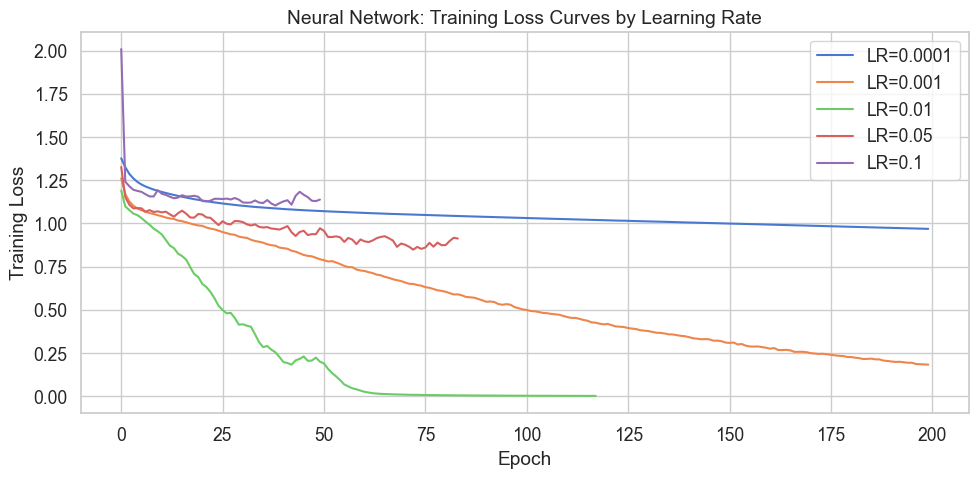

In [29]:
# Training loss curves for each learning rate
fig, ax = plt.subplots(figsize=(10, 5))
for lr, curve in loss_curves.items():
    ax.plot(curve, label=f'LR={lr}')
ax.set_xlabel('Epoch')
ax.set_ylabel('Training Loss')
ax.set_title('Neural Network: Training Loss Curves by Learning Rate')
ax.legend()
plt.tight_layout()
plt.show()

### Training Loss by Learning Rates Analysis
The above training loss curves showcases the efficiency of **Adam Optimizer** as it traverses the loss landscape to find the minimal multi-class cross entropy loss:

$$L = -\frac{1}{N} \sum_{i=1}^{N} \sum_{j=1}^{C} y_{i,j} \log(\hat{y}_{i,j})$$

Where $y_{i,j}$ is the binary indicater for class $j$ and $\hat{y}_{i,j}$ is the probability predicted. Each of the curves indicates the model's learning progress over the set epochs of $200$. As shown, the learning rate has the role of the primary determinant of both the speed of convergence and numerical stability.

The learning rate curves also showcases that at high rates, stochastic oscillation and early termination due to large step sizes, whereas at low rates, the model fails to converge within $200$ epochs. Then, the optimal stability is discivered at $0.01$ and $0.001$, with the loss decreases towards a functional minimum.

However, the drop of loss to almost $0$ at the learning rate of $0.01$ further confirms the state of high variance. At this point, the model has memorized training noise ignoring the required generalization, explaining the significant gap in performance between training and validation.

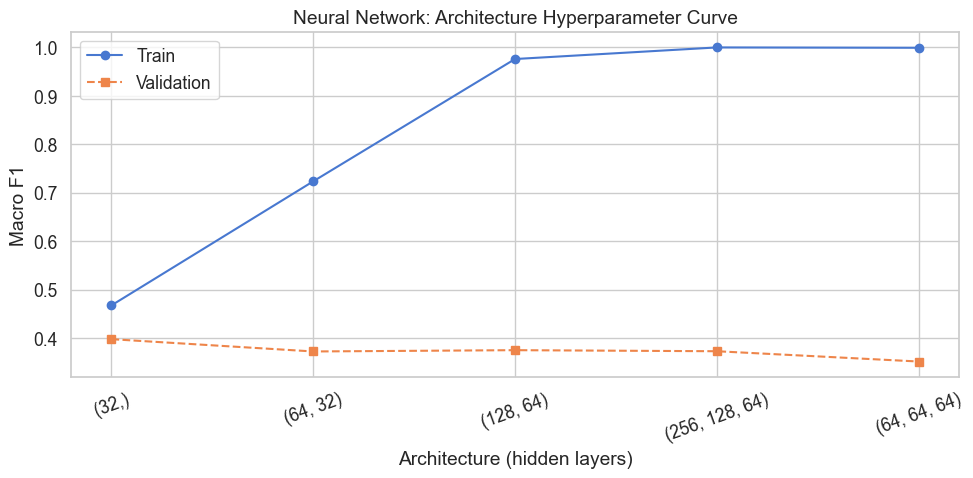

Best architecture: (32,)


In [30]:
# Hyperparameter 2: hidden_layer_sizes
architectures = [(32,), (64, 32), (128, 64), (256, 128, 64), (64, 64, 64)]
arch_labels   = [str(a) for a in architectures]
tr_f1s_arch, val_f1s_arch = [], []

for arch in architectures:
    mlp_a = MLPClassifier(
        hidden_layer_sizes=arch,
        learning_rate_init=best_lr,
        max_iter=200,
        random_state=SEED,
        solver='adam'
    )
    mlp_a.fit(X_train_sc, y_train)
    tr_f1s_arch.append(f1_score(y_train, mlp_a.predict(X_train_sc), average='macro'))
    val_f1s_arch.append(f1_score(y_val,  mlp_a.predict(X_val_sc),  average='macro'))

x_pos = range(len(architectures))
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(x_pos, tr_f1s_arch,  'o-', label='Train')
ax.plot(x_pos, val_f1s_arch, 's--', label='Validation')
ax.set_xticks(x_pos)
ax.set_xticklabels(arch_labels, rotation=20)
ax.set_xlabel('Architecture (hidden layers)')
ax.set_ylabel('Macro F1')
ax.set_title('Neural Network: Architecture Hyperparameter Curve')
ax.legend()
plt.tight_layout()
plt.show()

best_arch = architectures[int(np.argmax(val_f1s_arch))]
print(f'Best architecture: {best_arch}')

### Neural Network Optimization: Architecture Parameter Analysis
The `hidden_layer_sizes` parameter decides the model's architectural complexity, as well as its capacity in learning non-linear data. A single hidden layer consisting of $32$ neurons provides a somewhat simple of a mapping, while deep architectres like stacked hidden layers with neurons (256, 128, 64) provide the model with millions and maybe even more of parameters to capture complex and detailed interactions between atmospheric features and fire intensity.

The Architecture Hyperparam Curve above showcases one of the classic bias-variance tradeoffs. The simplest of the models with just $1$ hidden layer with $32$ neurons achieves the highest validation performance with a Macro F1-score of $~0.40$. As the architecture becomes more deep and complex, the training Macro F1-score goes up to a perfect $1$, with the validation score remaining stable and approching a slight decline. This indicates that as the network gets more deeper and complex, instead of generalizing over the fire patterns, the model uses its high capacity to memorize the specific training data (Overfitting). However, at the end, the $(32,)$ architecture is selected as the optimal as it has been able to maintain the most stable generalization.


  Neural Network (Best)
  Metric                  Train       Val
  --------------------------------------
  Accuracy               0.5683    0.4459
  Macro F1               0.5176    0.4039
  Weighted F1            0.5529    0.4323

  Per-class F1 (val):
    Low (0)         0.2110
    Moderate (1)    0.5436
    High (2)        0.3726
    Extreme (3)     0.4885

Classification Report (Validation):
              precision    recall  f1-score   support

     Low (0)       0.29      0.16      0.21       140
Moderate (1)       0.49      0.61      0.54       384
    High (2)       0.38      0.37      0.37       268
 Extreme (3)       0.58      0.42      0.49        76

    accuracy                           0.45       868
   macro avg       0.44      0.39      0.40       868
weighted avg       0.43      0.45      0.43       868



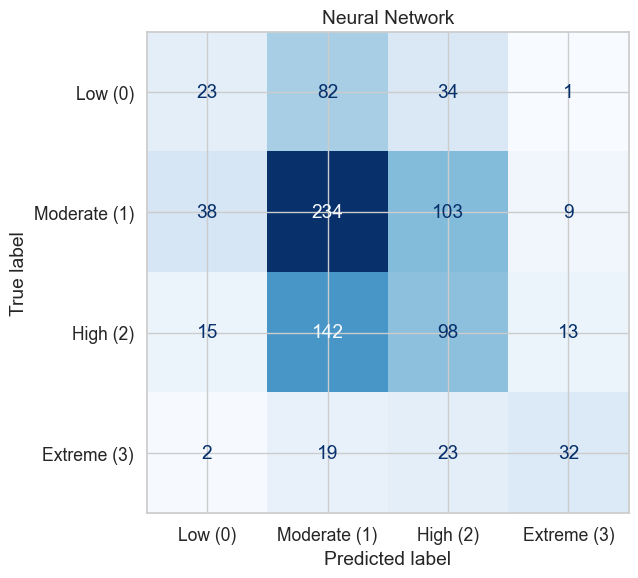

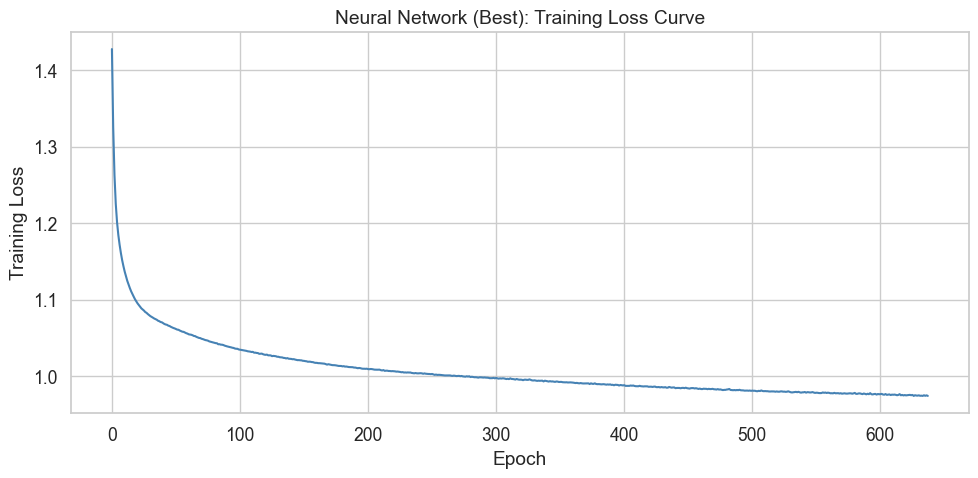

In [31]:
# final Neural Network model
nn_best = MLPClassifier(
    hidden_layer_sizes=best_arch,
    learning_rate_init=best_lr,
    max_iter=750,
    random_state=SEED,
    solver='adam',
    early_stopping=False
)
nn_best.fit(X_train_sc, y_train)

nn_tr_acc, nn_val_acc, nn_tr_f1, nn_val_f1, nn_tr_wf1, nn_val_wf1, nn_per_class = evaluate(
    nn_best, X_train_sc, y_train, X_val_sc, y_val, label='Neural Network (Best)'
)
print('\nClassification Report (Validation):')
print(classification_report(y_val, nn_best.predict(X_val_sc), target_names=CLASS_NAMES))
plot_confusion(nn_best, X_val_sc, y_val, 'Neural Network')

# final training loss curve
fig, ax = plt.subplots(figsize=FIGSIZE)
ax.plot(nn_best.loss_curve_, color='steelblue')
ax.set_xlabel('Epoch')
ax.set_ylabel('Training Loss')
ax.set_title('Neural Network (Best): Training Loss Curve')
plt.tight_layout()
plt.show()

### Performance and Behavior Analysis
#### Quantitative Performance:
The optimized Neural Network with an architecture of $(32,)$ and a learning rate $\eta$ of $0.001$ achieved a validation Macro F1-score of $0.4039$ as well as an Accuracy of $44.59%$. Even thoughm these metrics represents marginal improvements over the previous models, this model still contain a cap in predictive consistency across the different intensity level if fire.
> - **Generalization Gap**: The model has achieved a training Macro F1-score of $0.5176$ over the validation score of $0.4039$. While the $10%$ difference in scores still indicate the presense of some variance, it is important to note the improvements this model has made over the previous models and their behavior. The architecture's simplicity has also led the model to stabalize and reduce memorization of training noise.
> - **Weighted vs Macro F1-scores**: Since the weighted F1-score of $0.4323$ is slightly higher than the Macro F1-score of $0.4039$, it is clear that the model is still reliant on the majority class 'Moderate' for its overall accuracy, still somewhat struggling to achieve the same level of reliability in predicting rarer 'Low' class samples.



#### Behavior Analysis and Class Distribution:
The confusion matric above for the Neural Net gives a detailed insight at how the connectionist approach has handled the boundares between fire intensities.

> - 'Extreme' Class Success: This model has been able to effectively identify fires of 'Extreme' intensity with a Per-class F1-score of $0.4885$. $32$ of the 'Extreme' events were correctly identified, showcasing that the Neural Net's non-linear transformations are effective for distinct signatures of fires of higher intensities.
> - Boundary Ambiguity: Significant leakage into the 'Moderate' class can be seen just like the previous models. Specifically, $82$ of the 'Low' intensity fires as well as $142$ of the 'High' intensity fires were misclassified as 'Moderate'. This indicates that the features responsible have overlapping distributions that not even a neural network architecture can *perfectly* seperate.
> - 'Low' class: The model has aquired a lower Per-class F1-score of $0.2110$ for the 'Low' intensity class, whereas only $23$ samples were correctly predicted out of the entire $140$ samples. This confirms that the signal of 'Low' intensity fires is overshadowed by the dominant classes like 'Moderate' and 'High'.

The loss curve for training reveals a smooth, monotonic decrease of loss that comes to stabalize at around $0.97$ over $750$ epochs. This confirms that the learning rate of $0.001$ applied enabled a stable convergence without any unpleasent behavior.

## 3.5 Cross Validation on the Best Models

In [32]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

# DT; no scaling needed
dt_cv = cross_val_score(dt_best, X_imp, y, cv=skf, scoring='f1_macro', n_jobs=-1)

# SVM & NN: use scaled data
from sklearn.pipeline import make_pipeline

svm_pipe = make_pipeline(StandardScaler(),
    SVC(C=best_C, kernel='rbf', gamma=best_gamma, random_state=SEED))
svm_cv = cross_val_score(svm_pipe, X_imp, y, cv=skf, scoring='f1_macro', n_jobs=-1)

nn_pipe = make_pipeline(StandardScaler(),
    MLPClassifier(hidden_layer_sizes=best_arch, learning_rate_init=best_lr,
                  max_iter=750, random_state=SEED, solver='adam'))
nn_cv = cross_val_score(nn_pipe, X_imp, y, cv=skf, scoring='f1_macro', n_jobs=-1)

print('5-Fold Cross-Validation (Macro F1):')
print(f'  Decision Tree : {dt_cv.mean():.4f} ± {dt_cv.std():.4f}')
print(f'  SVM           : {svm_cv.mean():.4f} ± {svm_cv.std():.4f}')
print(f'  Neural Network: {nn_cv.mean():.4f} ± {nn_cv.std():.4f}')

5-Fold Cross-Validation (Macro F1):
  Decision Tree : 0.3742 ± 0.0083
  SVM           : 0.3637 ± 0.0205
  Neural Network: 0.3657 ± 0.0191


### Analysis:
The conducted 5-fold cross-validation reveals a stabalization in performance, where all three models are converging around a Macro F1-score of $0.37$. The results showcase that the Decision Tree model remains the superior baseline with the highest stability and the lowest variance across the $5$ folds. Whereas the SVM model and the Neural Net model show increased instability, with higher standard deviations than the baseline. This indicates that as these high capacity models try to identify complex non-linear boundaries, they become more sensitive to noise that are specific to certain folds, overfitting to local patterns quite often that do not infact generalize.

Just as discussed previously, these results confirm the existing feature level ceiling. The similarity of the Macro F1-scores across different types of models indicates that the existing atmospheric features do no have the required discriminative power for connectionisy models to outperform simple logic that is threshold-based.

## 3.6 Model Comparison and Final Selection

         Model  Train Acc  Val Acc  Train Macro-F1  Val Macro-F1  CV Macro-F1 mean  CV Macro-F1 std
 Decision Tree   0.482719 0.498848        0.374609      0.410983          0.374215         0.008350
           SVM   0.836118 0.433180        0.830417      0.379706          0.363681         0.020538
Neural Network   0.568260 0.445853        0.517586      0.403934          0.365700         0.019096


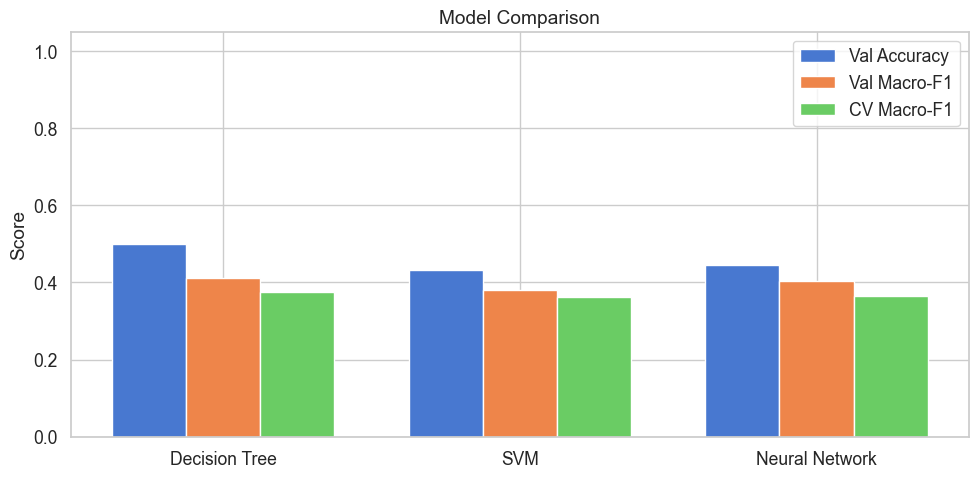

In [33]:
results = pd.DataFrame({
    'Model'       : ['Decision Tree', 'SVM', 'Neural Network'],
    'Train Acc'   : [dt_tr_acc,  svm_tr_acc,  nn_tr_acc],
    'Val Acc'     : [dt_val_acc, svm_val_acc, nn_val_acc],
    'Train Macro-F1': [dt_tr_f1,  svm_tr_f1,  nn_tr_f1],
    'Val Macro-F1': [dt_val_f1,  svm_val_f1,  nn_val_f1],
    'CV Macro-F1 mean': [dt_cv.mean(), svm_cv.mean(), nn_cv.mean()],
    'CV Macro-F1 std' : [dt_cv.std(),  svm_cv.std(),  nn_cv.std()],
})
print(results.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(3)
w = 0.25
models = ['Decision Tree', 'SVM', 'Neural Network']
ax.bar(x - w,   results['Val Acc'],      w, label='Val Accuracy')
ax.bar(x,       results['Val Macro-F1'], w, label='Val Macro-F1')
ax.bar(x + w,   results['CV Macro-F1 mean'], w, label='CV Macro-F1')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylabel('Score')
ax.set_ylim(0, 1.05)
ax.set_title('Model Comparison')
ax.legend()
plt.tight_layout()
plt.show()

### Performance Overview:
The three model achieve comparable validation Macro F1-scores in the range of $0.38-0.41$. Despite the differing learning mechanisms of the models, no one sinle model has been able to dominate across all the metrics, which is quite the meaningful finding.

### Breakdown: Model-by-Model:
**Decision Tree**: This model proves to be the most consistent performer. It achieves a validation Macro F1-score of $0.411$ which is the highest of the three models, and a CV Macro F1-score (also highest) of 0.374 with the lowest of the cross-validation standard deviation ($±0.008$). The slight gap between the train accuracy of $0.483$ and the validation accuracy of $0.499$ strengthen the confirmation that the model generalizes well without overfitting. The training and validation scores which are almost identical indicate that the model operates closer to the bias end of the bias-variance tradeoff, which is appropriate since the feature discriminability is limited.

**SVM**: This model shows rather a concerning pattern in this table, as its training Macro F1-score of $0.830$ is significantly higher (more than double) than its validation Macro F1-score of $0.380$. It is clear that this an overfitting signature as the RBF Kernel with `C`$=10$ has memorized the training set really well and fails to generalize. The SVM also holds the lowest of the CV Macro F1-score of $0.364$ and the highest of the CV standard deviation of $±0.021$ showcasing the model's failure in generalizing across folds. Despite the SVM's strengths in theory when it comes to high-dimensional spaces, the model proves to be the weakest performer.

**Neural Network**: This model sits between the first two models. It has a training Macro F1-score of $0.518$ and a Validation Macro F1-score of $0.404$ with a small gap than the SVM, yet still notable, indicating mild overfitting. The CV Macro F1-score of $0.366$ with a standard deviation of $±0.019$ is slightly better than the SVM yet falls short to the Decision Tree. The Neural Net managed to converge within $750$ epochs, indicating that the model was able to reach a stable solution. Despite achieving convergence, it remains inferior to the Decision tree in performance, confirming that the performance gap us ti attributable to insufficient training but rather the dataset's own limited feature discriminative power creating a ceiling across all the models constructed.


### Final Model Selection: Decision Tree
The Decision Tree was able to achieve the highest of both validation and cross-validation Macro F1-scores, the most stable generalization across the five folds, and showed no signs of overfitting. This model is also the most interpretable model, as in a real-world scenario of a wildfire emergency, explaining why a fire was classified as 'Extreme' (e.g. "brightness_k > 380K AND humidity < 30%") is a significant practical advantage over the other models, a black-box SVM or Neural net. Therefore, the Decision Tree model is chosen as the Final Model of this task.

Final model selected: DT

  FINAL MODEL
  Metric                  Train       Val
  --------------------------------------
  Accuracy               0.4827    0.4988
  Macro F1               0.3746    0.4110
  Weighted F1            0.4361    0.4543

  Per-class F1 (val):
    Low (0)         0.0000
    Moderate (1)    0.5809
    High (2)        0.4710
    Extreme (3)     0.5920


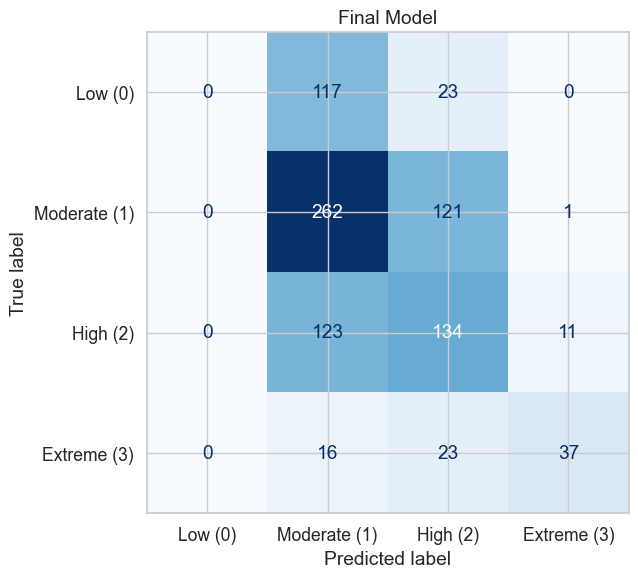

In [34]:
best_model_name = 'dt'

final_model   = dt_best
final_X_train = X_train
final_X_val   = X_val
final_X_test  = X_test_imp

print(f'Final model selected: {best_model_name.upper()}')
evaluate(final_model, final_X_train, y_train, final_X_val, y_val, label='FINAL MODEL')
plot_confusion(final_model, final_X_val, y_val, 'Final Model')

## 4.0 Test Predictions

In [35]:
test_preds = final_model.predict(final_X_test)

# Map integers back to string labels
label_map = {0: 'Low', 1: 'Moderate', 2: 'High', 3: 'Extreme'}
test_preds_str = pd.Series(test_preds).map(label_map)

submission = pd.DataFrame({
    'sample #': range(len(test_preds)),
    'fire_intensity_id': test_preds,       # integer class (0-3)
    'fire_intensity_label': test_preds_str # string label
})
submission.to_csv('test_predictions.csv', index=False)
print(f'Saved test_predictions.csv  ({len(test_preds)} rows)')
submission.head(10)

Saved test_predictions.csv  (1085 rows)


,sample #,fire_intensity_id,fire_intensity_label
0,0,2,High
1,1,3,Extreme
2,2,1,Moderate
3,3,2,High
4,4,1,Moderate
5,5,1,Moderate
6,6,2,High
7,7,1,Moderate
8,8,2,High
9,9,1,Moderate
